# Chapter 3 — GLM Frequency and Severity Modelling

### Chapter Overview

This chapter fits Generalised Linear Models (GLMs) for both claim
frequency and claim severity. GLMs are the actuarial industry standard
for insurance pricing and provide interpretable, statistically rigorous
baselines against which machine learning models are compared in Chapter 4.

| Section | Activity |
|---------|----------|
| 3.1 | Import libraries and load data |
| 3.2 | Build GLM training frames |
| 3.3 | Frequency Model 1 — Poisson Regression |
| 3.4 | Frequency Model 2 — Negative Binomial Regression |
| 3.5 | Frequency model comparison |
| 3.6 | Severity Model 1 — Gamma Regression |
| 3.7 | Severity Model 2 — Lognormal Regression |
| 3.8 | Severity model comparison |
| 3.9 | Save models |

### GLM Framework

| Task | Target | Distribution | Link Function |
|------|--------|-------------|---------------|
| Frequency | ClaimNb | Poisson / Negative Binomial | Log |
| Severity | ClaimAmount | Gamma / Lognormal | Log |

### Modelling Decisions

| Decision | Choice | Justification |
|----------|--------|---------------|
| Frequency offset | log(Exposure) | Accounts for varying policy durations |
| Severity subset | ClaimAmount > 0 only | Severity conditioned on claim occurring |
| Link function | Log | Ensures positive fitted values |
| Evaluation | AIC, BIC, Deviance | Standard GLM comparison criteria |

> **Research connection:** This chapter directly addresses RQ1 (Poisson
> vs Negative Binomial) and RQ2 (Gamma vs Lognormal) from Chapter 0.

---


# ── 3.1 IMPORTS AND LOAD ─────────────────────────────────────
### 3.1 Import Libraries and Load Data


In [1]:
# ── Standard libraries ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Statsmodels ───────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Sklearn metrics ───────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_prepared_data

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ── Load prepared data ────────────────────────────────────────
data = load_prepared_data()

df           = data['df']
df_sev       = data['df_severity']
y_freq_train = data['y_freq_train']
y_freq_test  = data['y_freq_test']
y_sev_train  = data['y_sev_train']
y_sev_test   = data['y_sev_test']
exp_train    = data['exposure_train']
exp_test     = data['exposure_test']
X_freq_train = data['X_freq_train']
X_freq_test  = data['X_freq_test']
X_sev_train  = data['X_sev_train']
X_sev_test   = data['X_sev_test']

# ── Set up paths ──────────────────────────────────────────────
def find_dir(name):
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, name)
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)
    path = os.path.join(os.path.dirname(os.getcwd()), name)
    os.makedirs(path, exist_ok=True)
    return path

PLOTS_DIR  = find_dir('plots')
MODELS_DIR = find_dir('models')

print(f"Data loaded.")
print(f"   Frequency train : {len(y_freq_train):,} rows")
print(f"   Severity train  : {len(y_sev_train):,} rows")


Loading prepared data from data/ folder...
All datasets loaded successfully.
   Full dataset     : (678013, 47)
   Severity subset  : (24944, 47)
   Freq train/test  : (542410, 44) / (135603, 44)
   Sev  train/test  : (19955, 44) / (4989, 44)
Data loaded.
   Frequency train : 542,410 rows
   Severity train  : 19,955 rows


# ── 3.2 BUILD GLM FRAMES ─────────────────────────────────────
### 3.2 Build GLM Training Frames

The statsmodels formula API requires a single dataframe containing
both features and target. We reload the raw files here and rebuild
clean training frames with the original categorical columns intact,
these are needed for the formula interface to work correctly.


In [5]:
# ── Reload raw files to get original categorical columns ─────
def find_data_dir():
    current = os.getcwd()
    for _ in range(4):
        candidate = os.path.join(current, 'data')
        if os.path.exists(candidate):
            return candidate
        current = os.path.dirname(current)
    raise FileNotFoundError("data/ folder not found.")

DATA_DIR = find_data_dir()

freq_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'freMTPL2freq.csv.zip'),
    compression='zip'
)
sev_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'freMTPL2sev.csv')
)

print(f"Raw files reloaded.")
print(f"   Frequency : {freq_raw.shape}")
print(f"   Severity  : {sev_raw.shape}")


Raw files reloaded.
   Frequency : (678013, 12)
   Severity  : (26639, 2)


In [6]:
# ── Rebuild merged dataset with original categoricals ─────────
# Aggregate severity and merge
sev_agg = (sev_raw
           .groupby('IDpol')
           .agg(ClaimAmount=('ClaimAmount','sum'))
           .reset_index())

df_raw = freq_raw.merge(sev_agg, on='IDpol', how='left')
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].fillna(0)

# Apply same cap as Chapter 1
cap = df_raw[df_raw['ClaimAmount']>0]['ClaimAmount'].quantile(0.995)
df_raw['ClaimAmount'] = df_raw['ClaimAmount'].clip(upper=cap)

# Add engineered features
df_raw['LogDensity']  = np.log1p(df_raw['Density'])
df_raw['LogExposure'] = np.log(df_raw['Exposure'])

# Drop IDpol
df_raw.drop(columns=['IDpol'], inplace=True)

print(f"Raw merged dataset rebuilt: {df_raw.shape}")
print(f"   Columns: {df_raw.columns.tolist()}")


Raw merged dataset rebuilt: (678013, 14)
   Columns: ['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region', 'ClaimAmount', 'LogDensity', 'LogExposure']


In [7]:
# ── Build frequency GLM train/test frames ────────────────────
# Use the same indices as the saved split from Chapter 1
# X_freq_train index gives us the training rows

freq_train_idx = X_freq_train.index.tolist()
freq_test_idx  = X_freq_test.index.tolist()

# GLM frame needs original categoricals + targets
freq_glm_cols  = [
    'ClaimNb', 'ClaimAmount', 'Exposure', 'LogExposure',
    'VehPower', 'VehAge', 'DrivAge', 'BonusMalus',
    'VehBrand', 'VehGas', 'Area', 'Region',
    'Density', 'LogDensity'
]
freq_glm_cols  = [c for c in freq_glm_cols if c in df_raw.columns]

freq_train_glm = df_raw[freq_glm_cols].iloc[freq_train_idx].reset_index(drop=True)
freq_test_glm  = df_raw[freq_glm_cols].iloc[freq_test_idx].reset_index(drop=True)

# Attach correct targets
freq_train_glm['ClaimNb'] = y_freq_train.values
freq_test_glm['ClaimNb']  = y_freq_test.values
freq_train_glm['LogExposure'] = np.log(freq_train_glm['Exposure'])
freq_test_glm['LogExposure']  = np.log(freq_test_glm['Exposure'])

print(f"Frequency GLM frames built.")
print(f"   Train : {freq_train_glm.shape}")
print(f"   Test  : {freq_test_glm.shape}")
print(f"   Columns available: {freq_train_glm.columns.tolist()}")


Frequency GLM frames built.
   Train : (542410, 14)
   Test  : (135603, 14)
   Columns available: ['ClaimNb', 'ClaimAmount', 'Exposure', 'LogExposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Region', 'Density', 'LogDensity']


In [8]:
# ── Build severity GLM train/test frames ─────────────────────
# Severity subset — claims only
df_sev_raw = df_raw[df_raw['ClaimAmount'] > 0].reset_index(drop=True)

sev_glm_cols = [
    'ClaimAmount', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'VehBrand', 'VehGas', 'Area',
    'Region', 'Density', 'LogDensity'
]
sev_glm_cols = [c for c in sev_glm_cols if c in df_sev_raw.columns]

# Split severity 80/20
split_idx = int(len(df_sev_raw) * 0.8)
sev_train_glm = df_sev_raw[sev_glm_cols].iloc[:split_idx].reset_index(drop=True)
sev_test_glm  = df_sev_raw[sev_glm_cols].iloc[split_idx:].reset_index(drop=True)

# Attach correct targets
sev_train_glm['ClaimAmount'] = df_sev_raw['ClaimAmount'].iloc[:split_idx].values
sev_test_glm['ClaimAmount']  = df_sev_raw['ClaimAmount'].iloc[split_idx:].values

y_sev_test_glm = sev_test_glm['ClaimAmount'].copy()

print(f"Severity GLM frames built.")
print(f"   Train : {sev_train_glm.shape}")
print(f"   Test  : {sev_test_glm.shape}")

# Verify categorical columns exist
for col in ['VehGas', 'Area', 'VehBrand']:
    print(f"   {col} unique values: {freq_train_glm[col].nunique()}")


Severity GLM frames built.
   Train : (19955, 11)
   Test  : (4989, 11)
   VehGas unique values: 2
   Area unique values: 6
   VehBrand unique values: 11


# ── 3.3 POISSON REGRESSION ───────────────────────────────────
### 3.3 Frequency Model 1 — Poisson Regression

Poisson regression is the standard actuarial baseline for modelling
claim counts. It models the log of the expected claim rate as a linear
combination of policyholder features.

The offset term `log(Exposure)` ensures the model predicts claim rate
per unit of exposure rather than raw claim count, essential when
policies have different durations.

**Assumption being tested:** Poisson assumes variance = mean. The
overdispersion test in Chapter 2 found a dispersion index of 1.083,
suggesting this may not hold motivating the Negative Binomial model
in Section 3.4.


In [9]:
# ── Define frequency formula ──────────────────────────────────
# C() wraps categorical columns for automatic dummy encoding in the statsmodels formula interface
freq_formula = (
    'ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus '
    '+ LogDensity + C(VehGas) + C(Area) + C(VehBrand)'
)

print("Formula defined:")
print(f"   {freq_formula}")
print()

# Confirm all formula variables exist in training frame
formula_vars = [
    'ClaimNb', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'LogDensity', 'VehGas', 'Area', 'VehBrand'
]
for var in formula_vars:
    exists = var in freq_train_glm.columns
    print(f"   {var:<15} : {'OK' if exists else 'MISSING'}")


Formula defined:
   ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + LogDensity + C(VehGas) + C(Area) + C(VehBrand)

   ClaimNb         : OK
   VehPower        : OK
   VehAge          : OK
   DrivAge         : OK
   BonusMalus      : OK
   LogDensity      : OK
   VehGas          : OK
   Area            : OK
   VehBrand        : OK


In [10]:
# ── Fit Poisson GLM ───────────────────────────────────────────
print("Fitting Poisson Regression...")

poisson_model = smf.glm(
    formula = freq_formula,
    data    = freq_train_glm,
    family  = sm.families.Poisson(
        link=sm.families.links.Log()
    ),
    offset  = freq_train_glm['LogExposure']
).fit()

print("Poisson model fitted.")
print(f"   AIC      : {poisson_model.aic:.2f}")
print(f"   BIC      : {poisson_model.bic:.2f}")
print(f"   Deviance : {poisson_model.deviance:.2f}")
print(f"   Df Resid : {poisson_model.df_resid:.0f}")


Fitting Poisson Regression...
Poisson model fitted.
   AIC      : 253343.69
   BIC      : -6963721.49
   Deviance : 197848.96
   Df Resid : 542388


In [11]:
# ── Significant Poisson coefficients ─────────────────────────
coef_df = pd.DataFrame({
    'Coefficient': poisson_model.params,
    'Std Error'  : poisson_model.bse,
    'p-value'    : poisson_model.pvalues,
    'Exp(Coef)'  : np.exp(poisson_model.params)
}).round(4)

sig = coef_df[coef_df['p-value'] < 0.05].sort_values(
    'Exp(Coef)', ascending=False
)
print("Significant Poisson Coefficients (p < 0.05):")
print("Exp(Coef) = multiplicative effect on claim rate")
print(sig.to_string())


Significant Poisson Coefficients (p < 0.05):
Exp(Coef) = multiplicative effect on claim rate
                      Coefficient  Std Error  p-value  Exp(Coef)
C(VehBrand)[T.B12]         0.2995     0.0197   0.0000     1.3491
C(VehBrand)[T.B11]         0.1268     0.0422   0.0027     1.1351
VehPower                   0.0067     0.0032   0.0368     1.0067
BonusMalus                 0.0067     0.0004   0.0000     1.0067
DrivAge                   -0.0056     0.0005   0.0000     0.9944
VehAge                    -0.0076     0.0012   0.0000     0.9925
C(VehBrand)[T.B2]         -0.0330     0.0163   0.0433     0.9675
C(VehBrand)[T.B5]         -0.0610     0.0277   0.0274     0.9408
C(VehGas)[T.Regular]      -0.0822     0.0122   0.0000     0.9211
Intercept                 -2.5798     0.0661   0.0000     0.0758


In [12]:
# ── Poisson predictions ───────────────────────────────────────
poisson_pred = poisson_model.predict(
    freq_test_glm,
    offset=freq_test_glm['LogExposure']
)

pearson_resid = (
    (y_freq_test.values - poisson_pred.values) /
    np.sqrt(poisson_pred.values + 1e-10)
)

print(f"Poisson Predictions:")
print(f"   Mean predicted : {poisson_pred.mean():.6f}")
print(f"   Mean actual    : {y_freq_test.mean():.6f}")
print(f"   Pearson resid std : {pearson_resid.std():.4f}")


Poisson Predictions:
   Mean predicted : 0.058639
   Mean actual    : 0.053362
   Pearson resid std : 2.1286


# ── 3.4 NEGATIVE BINOMIAL ────────────────────────────────────
### 3.4 Frequency Model 2 — Negative Binomial Regression

Negative Binomial regression extends Poisson by introducing a
dispersion parameter α that allows variance to exceed the mean:
Var(ClaimNb) = μ + α·μ²
When α approaches 0, NB reduces to Poisson. A significant α
confirms overdispersion and justifies NB over Poisson.
The same formula and offset as Poisson is used for direct comparison.


In [14]:
import warnings
warnings.filterwarnings('ignore')

# ── Fit Negative Binomial GLM ────────────────────────────────
print("Fitting Negative Binomial Regression...")

nb_model = smf.glm(
    formula = freq_formula,
    data    = freq_train_glm,
    family  = sm.families.NegativeBinomial(
        link=sm.families.links.Log()
    ),
    offset  = freq_train_glm['LogExposure']
).fit()

print("Negative Binomial model fitted.")
print(f"   AIC      : {nb_model.aic:.2f}")
print(f"   BIC      : {nb_model.bic:.2f}")
print(f"   Deviance : {nb_model.deviance:.2f}")
print(f"   Df Resid : {nb_model.df_resid:.0f}")


Fitting Negative Binomial Regression...
Negative Binomial model fitted.
   AIC      : 251759.16
   BIC      : -6987034.78
   Deviance : 174535.66
   Df Resid : 542388


In [15]:
# ── Negative Binomial predictions ────────────────────────────
nb_pred = nb_model.predict(
    freq_test_glm,
    offset=freq_test_glm['LogExposure']
)

nb_pearson_resid = (
    (y_freq_test.values - nb_pred.values) /
    np.sqrt(nb_pred.values + 1e-10)
)

print(f"Negative Binomial Predictions:")
print(f"   Mean predicted : {nb_pred.mean():.6f}")
print(f"   Mean actual    : {y_freq_test.mean():.6f}")
print(f"   Pearson resid std : {nb_pearson_resid.std():.4f}")


Negative Binomial Predictions:
   Mean predicted : 0.060020
   Mean actual    : 0.053362
   Pearson resid std : 2.1034


# ── 3.5 FREQUENCY COMPARISON ─────────────────────────────────
### 3.5 Frequency Model Comparison

Poisson and Negative Binomial models are compared using AIC, BIC,
deviance, residual plots and QQ-plots.


In [16]:
# ── Frequency comparison table ───────────────────────────────
freq_comparison = pd.DataFrame([
    {
        'Model'   : 'Poisson',
        'AIC'     : round(poisson_model.aic, 2),
        'BIC'     : round(poisson_model.bic, 2),
        'Deviance': round(poisson_model.deviance, 2),
        'Df Resid': int(poisson_model.df_resid)
    },
    {
        'Model'   : 'Negative Binomial',
        'AIC'     : round(nb_model.aic, 2),
        'BIC'     : round(nb_model.bic, 2),
        'Deviance': round(nb_model.deviance, 2),
        'Df Resid': int(nb_model.df_resid)
    }
])

print("Frequency Model Comparison (lower = better):")
print("=" * 60)
print(freq_comparison.to_string(index=False))
print("=" * 60)

best_freq = freq_comparison.loc[
    freq_comparison['AIC'].idxmin(), 'Model'
]
print(f"\\nBest frequency model by AIC: {best_freq}")


Frequency Model Comparison (lower = better):
            Model       AIC         BIC  Deviance  Df Resid
          Poisson 253343.69 -6963721.49 197848.96    542388
Negative Binomial 251759.16 -6987034.78 174535.66    542388
\nBest frequency model by AIC: Negative Binomial


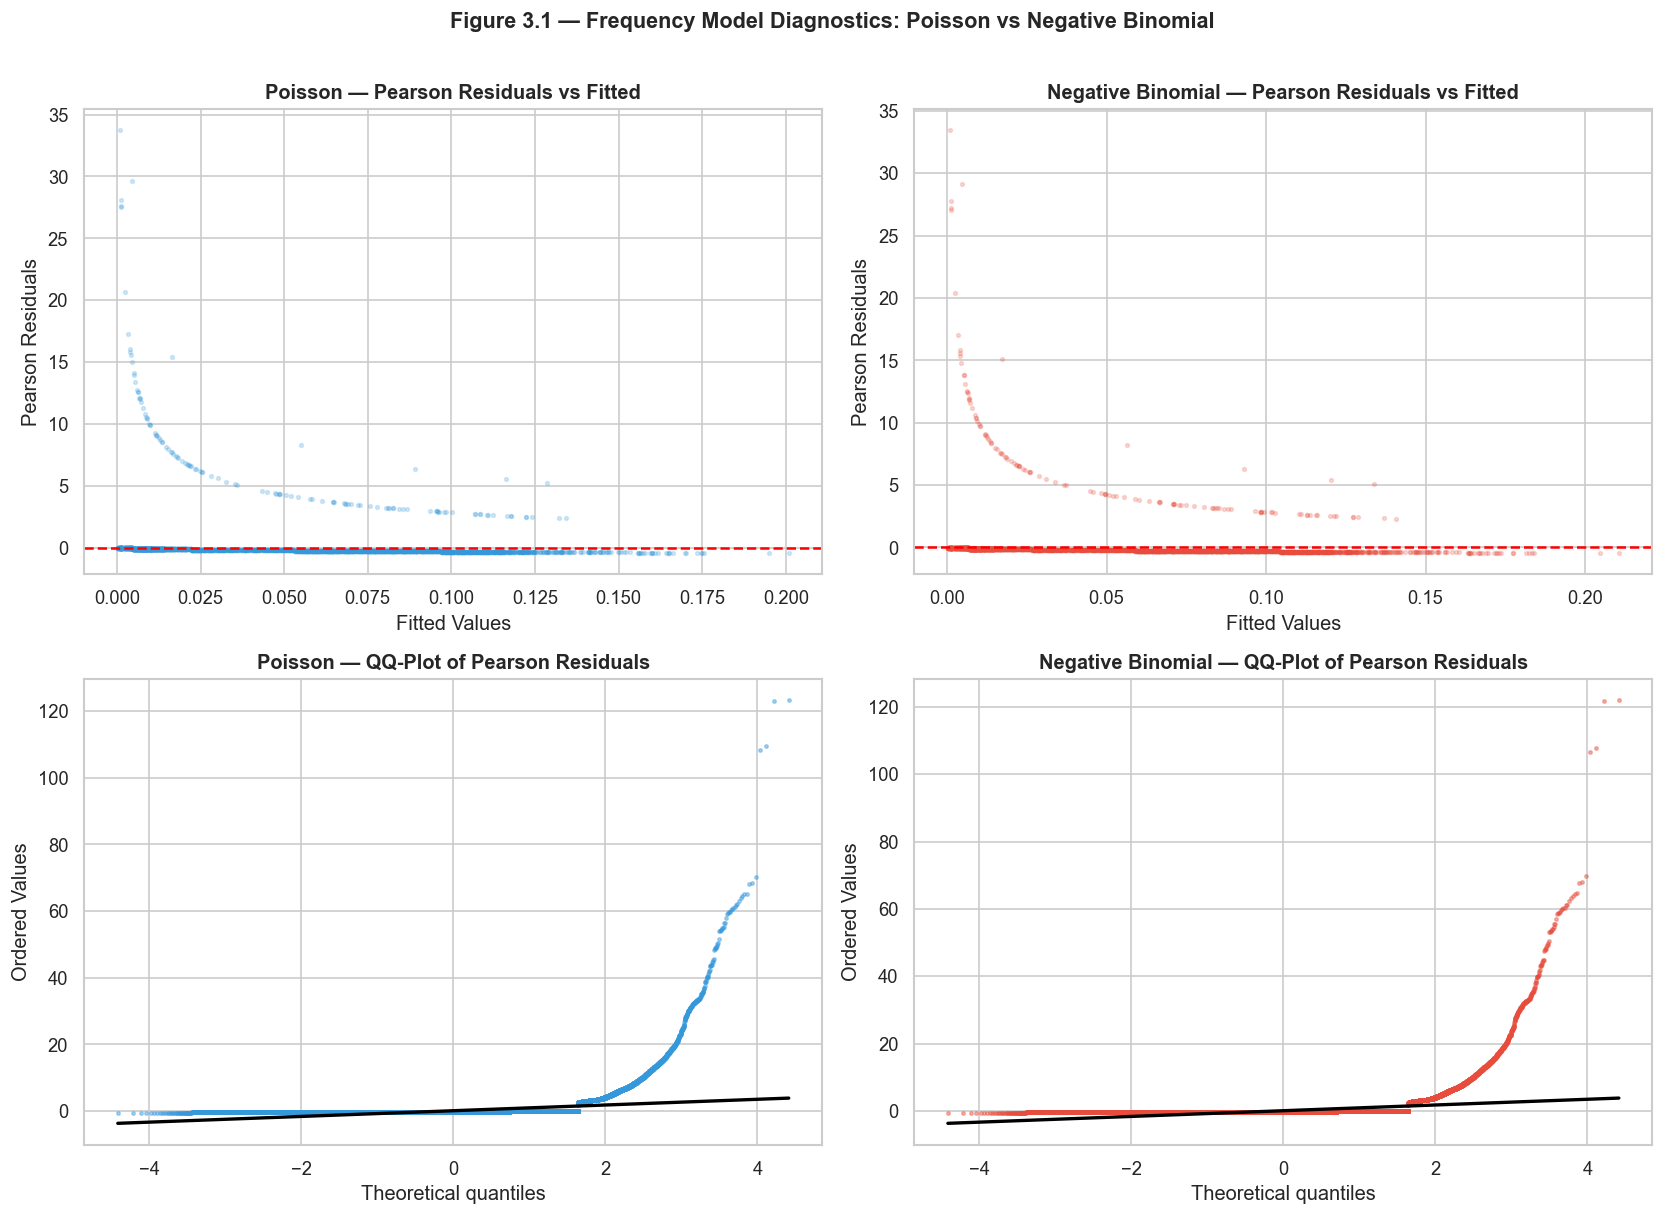

Saved to plots/fig3_1_freq_diagnostics.png


In [17]:
# ── Figure 3.1: Frequency model diagnostics ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top left: Poisson residuals vs fitted ─────────────────────
axes[0,0].scatter(
    poisson_pred.values[:3000],
    pearson_resid[:3000],
    alpha=0.2, s=5, color='#3498db'
)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Poisson — Pearson Residuals vs Fitted')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Pearson Residuals')

# ── Top right: NB residuals vs fitted ────────────────────────
axes[0,1].scatter(
    nb_pred.values[:3000],
    nb_pearson_resid[:3000],
    alpha=0.2, s=5, color='#e74c3c'
)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Negative Binomial — Pearson Residuals vs Fitted')
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Pearson Residuals')

# ── Bottom left: QQ-plot Poisson ──────────────────────────────
stats.probplot(pearson_resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Poisson — QQ-Plot of Pearson Residuals')
axes[1,0].get_lines()[0].set(color='#3498db', markersize=2, alpha=0.4)
axes[1,0].get_lines()[1].set(color='black', linewidth=2)

# ── Bottom right: QQ-plot NB ──────────────────────────────────
stats.probplot(nb_pearson_resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Negative Binomial — QQ-Plot of Pearson Residuals')
axes[1,1].get_lines()[0].set(color='#e74c3c', markersize=2, alpha=0.4)
axes[1,1].get_lines()[1].set(color='black', linewidth=2)

plt.suptitle(
    'Figure 3.1 — Frequency Model Diagnostics: Poisson vs Negative Binomial',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig3_1_freq_diagnostics.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig3_1_freq_diagnostics.png")


# ── 3.6 GAMMA REGRESSION ─────────────────────────────────────
### 3.6 Severity Model 1 — Gamma Regression

Gamma regression is the actuarial standard for claim severity.
It is strictly positive, right skewed and uses a log link matching
the empirical properties of ClaimAmount from Chapter 2.
Fitted on claims only subset.


In [18]:
# ── Define severity formula ───────────────────────────────────
sev_formula = (
    'ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus '
    '+ LogDensity + C(VehGas) + C(Area) + C(VehBrand)'
)

# Confirm all columns exist in severity training frame
print("Severity formula column check:")
sev_vars = [
    'ClaimAmount', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'LogDensity', 'VehGas', 'Area', 'VehBrand'
]
for var in sev_vars:
    exists = var in sev_train_glm.columns
    print(f"   {var:<15} : {'OK' if exists else 'MISSING'}")


Severity formula column check:
   ClaimAmount     : OK
   VehPower        : OK
   VehAge          : OK
   DrivAge         : OK
   BonusMalus      : OK
   LogDensity      : OK
   VehGas          : OK
   Area            : OK
   VehBrand        : OK


In [19]:
# ── Fit Gamma GLM ─────────────────────────────────────────────
print("\\nFitting Gamma Regression...")

gamma_model = smf.glm(
    formula = sev_formula,
    data    = sev_train_glm,
    family  = sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit()

print("Gamma model fitted.")
print(f"   AIC      : {gamma_model.aic:.2f}")
print(f"   BIC      : {gamma_model.bic:.2f}")
print(f"   Deviance : {gamma_model.deviance:.2f}")
print(f"   Df Resid : {gamma_model.df_resid:.0f}")


\nFitting Gamma Regression...
Gamma model fitted.
   AIC      : 354077.98
   BIC      : -172419.80
   Deviance : 24941.52
   Df Resid : 19933


In [20]:
# ── Gamma predictions ─────────────────────────────────────────
gamma_pred = gamma_model.predict(sev_test_glm)

gamma_resid = (
    (y_sev_test_glm.values - gamma_pred.values) /
    (gamma_pred.values + 1e-10)
)

print(f"Gamma Predictions:")
print(f"   Mean predicted : EUR {gamma_pred.mean():,.2f}")
print(f"   Mean actual    : EUR {y_sev_test_glm.mean():,.2f}")
print(f"   RMSE : EUR {np.sqrt(mean_squared_error(y_sev_test_glm, gamma_pred)):,.2f}")
print(f"   MAE  : EUR {mean_absolute_error(y_sev_test_glm, gamma_pred):,.2f}")


Gamma Predictions:
   Mean predicted : EUR 1,803.38
   Mean actual    : EUR 1,844.15
   RMSE : EUR 3,293.00
   MAE  : EUR 1,321.17


# ── 3.7 LOGNORMAL REGRESSION ─────────────────────────────────
### 3.7 Severity Model 2 — Lognormal Regression

Lognormal regression models log(ClaimAmount) as normally distributed.
The Chapter 2 QQ-plot confirmed log(ClaimAmount) approximates normality.

Predictions are back-transformed with bias correction:
E[ClaimAmount] = exp(μ + σ²/2)


In [21]:
# ── Fit Lognormal regression (OLS on log target) ─────────────
print("Fitting Lognormal Regression...")

sev_train_glm['LogClaimAmount'] = np.log(
    sev_train_glm['ClaimAmount'].clip(lower=1)
)
sev_test_glm['LogClaimAmount']  = np.log(
    sev_test_glm['ClaimAmount'].clip(lower=1)
)

lognormal_formula = (
    'LogClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus '
    '+ LogDensity + C(VehGas) + C(Area) + C(VehBrand)'
)

lognormal_model = smf.ols(
    formula = lognormal_formula,
    data    = sev_train_glm
).fit()

sigma2 = lognormal_model.mse_resid

print("Lognormal model fitted.")
print(f"   AIC      : {lognormal_model.aic:.2f}")
print(f"   BIC      : {lognormal_model.bic:.2f}")
print(f"   R-squared: {lognormal_model.rsquared:.4f}")
print(f"   Sigma2   : {sigma2:.4f}")


Fitting Lognormal Regression...
Lognormal model fitted.
   AIC      : 62029.40
   BIC      : 62203.22
   R-squared: 0.0168
   Sigma2   : 1.3093


In [22]:
# ── Lognormal predictions with bias correction ───────────────
log_pred       = lognormal_model.predict(sev_test_glm)
lognormal_pred = np.exp(log_pred + sigma2 / 2)

lognormal_resid = (
    (y_sev_test_glm.values - lognormal_pred.values) /
    (lognormal_pred.values + 1e-10)
)

print(f"Lognormal Predictions:")
print(f"   Mean predicted : EUR {lognormal_pred.mean():,.2f}")
print(f"   Mean actual    : EUR {y_sev_test_glm.mean():,.2f}")
print(f"   RMSE : EUR {np.sqrt(mean_squared_error(y_sev_test_glm, lognormal_pred)):,.2f}")
print(f"   MAE  : EUR {mean_absolute_error(y_sev_test_glm, lognormal_pred):,.2f}")


Lognormal Predictions:
   Mean predicted : EUR 1,946.52
   Mean actual    : EUR 1,844.15
   RMSE : EUR 3,295.95
   MAE  : EUR 1,421.83


# ── 3.8 SEVERITY COMPARISON ──────────────────────────────────
### 3.8 Severity Model Comparison


In [23]:
# ── Severity comparison table ────────────────────────────────
sev_comparison = pd.DataFrame([
    {
        'Model'   : 'Gamma',
        'AIC'     : round(gamma_model.aic, 2),
        'BIC'     : round(gamma_model.bic, 2),
        'Deviance': round(gamma_model.deviance, 2),
        'RMSE'    : round(np.sqrt(mean_squared_error(
                        y_sev_test_glm, gamma_pred)), 2),
        'MAE'     : round(mean_absolute_error(
                        y_sev_test_glm, gamma_pred), 2)
    },
    {
        'Model'   : 'Lognormal',
        'AIC'     : round(lognormal_model.aic, 2),
        'BIC'     : round(lognormal_model.bic, 2),
        'Deviance': round(lognormal_model.ssr, 2),
        'RMSE'    : round(np.sqrt(mean_squared_error(
                        y_sev_test_glm, lognormal_pred)), 2),
        'MAE'     : round(mean_absolute_error(
                        y_sev_test_glm, lognormal_pred), 2)
    }
])

print("Severity Model Comparison (lower = better):")
print("=" * 65)
print(sev_comparison.to_string(index=False))
print("=" * 65)

best_sev = sev_comparison.loc[
    sev_comparison['AIC'].idxmin(), 'Model'
]
print(f"\\nBest severity model by AIC: {best_sev}")


Severity Model Comparison (lower = better):
    Model       AIC        BIC  Deviance    RMSE     MAE
    Gamma 354077.98 -172419.80  24941.52 3293.00 1321.17
Lognormal  62029.40   62203.22  26098.07 3295.95 1421.83
\nBest severity model by AIC: Lognormal


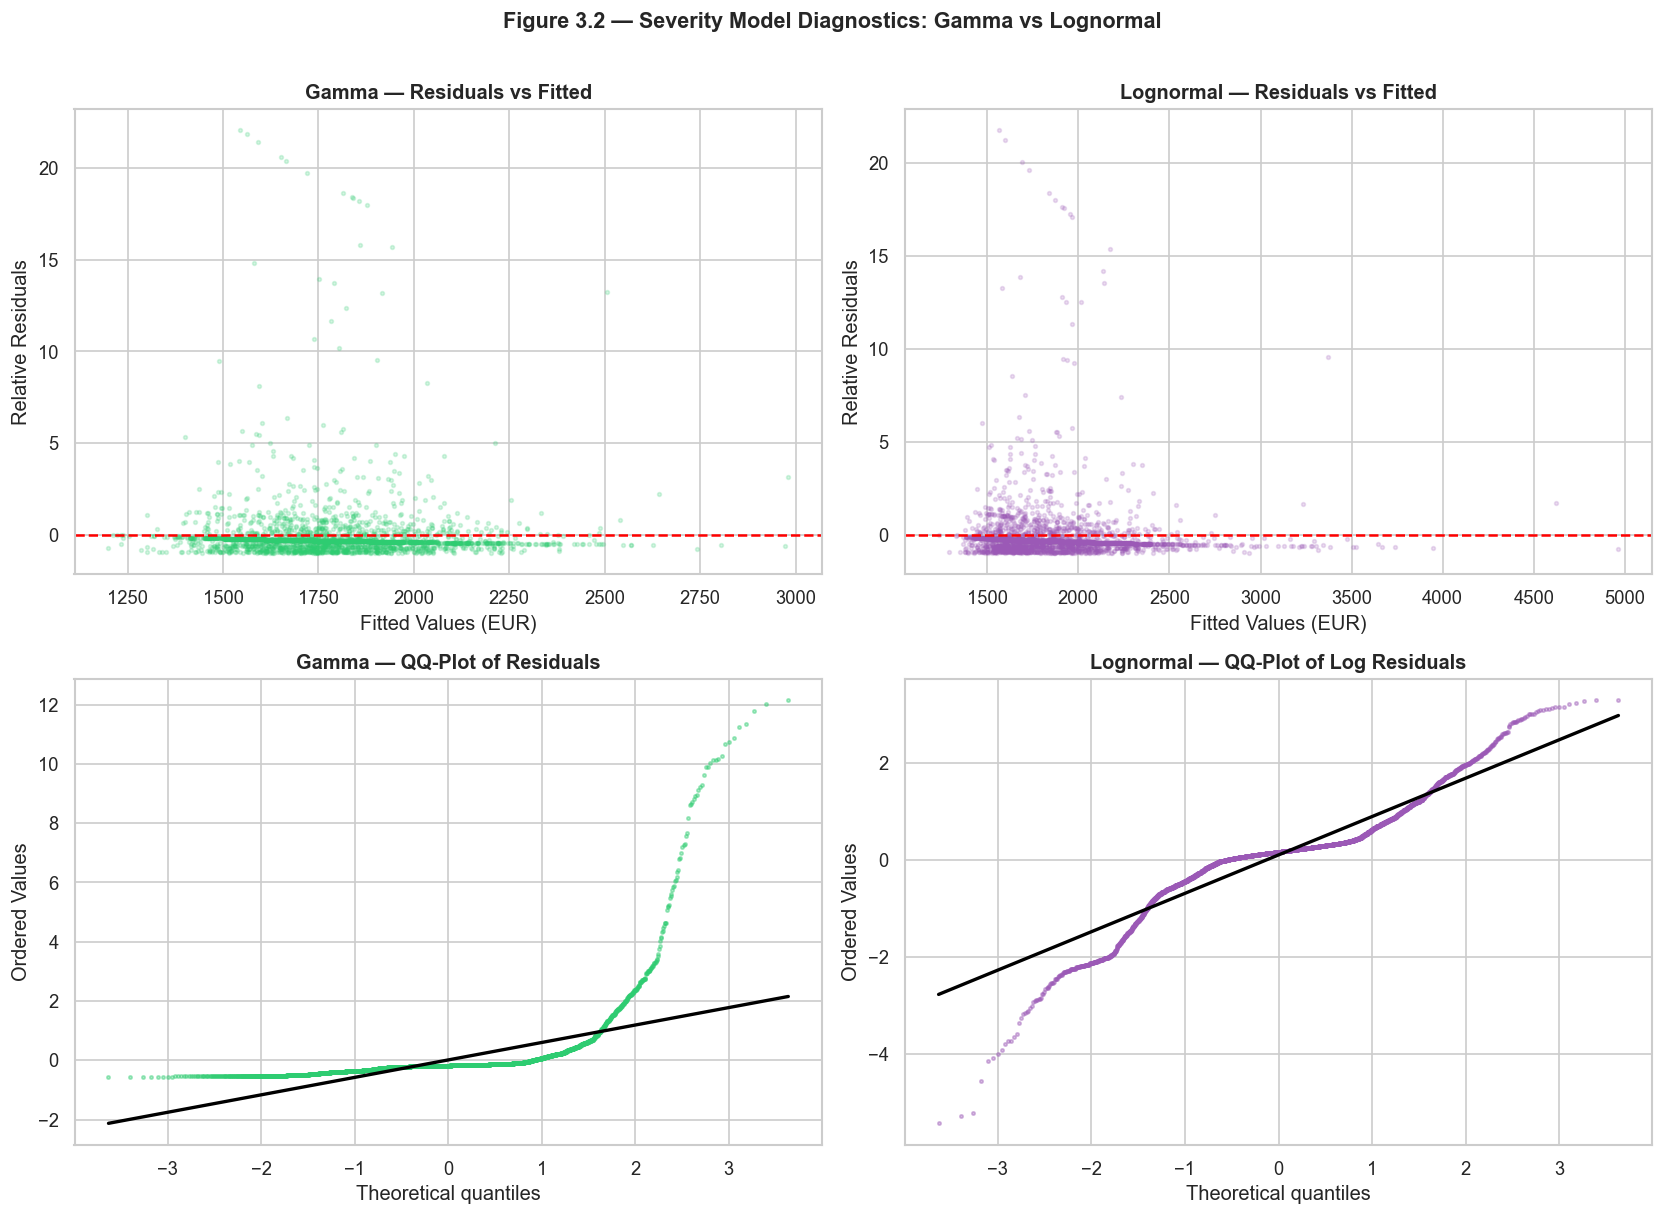

Saved to plots/fig3_2_sev_diagnostics.png


In [24]:
# ── Figure 3.2: Severity model diagnostics ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top left: Gamma residuals vs fitted ──────────────────────
axes[0,0].scatter(
    gamma_pred.values[:3000],
    gamma_resid[:3000],
    alpha=0.2, s=5, color='#2ecc71'
)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Gamma — Residuals vs Fitted')
axes[0,0].set_xlabel('Fitted Values (EUR)')
axes[0,0].set_ylabel('Relative Residuals')

# ── Top right: Lognormal residuals vs fitted ──────────────────
axes[0,1].scatter(
    lognormal_pred.values[:3000],
    lognormal_resid[:3000],
    alpha=0.2, s=5, color='#9b59b6'
)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Lognormal — Residuals vs Fitted')
axes[0,1].set_xlabel('Fitted Values (EUR)')
axes[0,1].set_ylabel('Relative Residuals')

# ── Bottom left: QQ-plot Gamma ────────────────────────────────
gamma_std = gamma_resid / (gamma_resid.std() + 1e-10)
stats.probplot(gamma_std, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Gamma — QQ-Plot of Residuals')
axes[1,0].get_lines()[0].set(color='#2ecc71', markersize=2, alpha=0.4)
axes[1,0].get_lines()[1].set(color='black', linewidth=2)

# ── Bottom right: QQ-plot Lognormal ──────────────────────────
ln_std = (
    sev_test_glm['LogClaimAmount'].values - log_pred.values
) / (np.sqrt(sigma2) + 1e-10)
stats.probplot(ln_std, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Lognormal — QQ-Plot of Log Residuals')
axes[1,1].get_lines()[0].set(color='#9b59b6', markersize=2, alpha=0.4)
axes[1,1].get_lines()[1].set(color='black', linewidth=2)

plt.suptitle(
    'Figure 3.2 — Severity Model Diagnostics: Gamma vs Lognormal',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'fig3_2_sev_diagnostics.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to plots/fig3_2_sev_diagnostics.png")


# ── 3.9 SAVE MODELS ──────────────────────────────────────────
### 3.9 Save Models

All four fitted GLM models are saved to the `models/` folder.
Chapters 4 and 5 load these directly without refitting.


In [25]:
# ── Save all GLM models ───────────────────────────────────────
print("Saving GLM models...")

joblib.dump(poisson_model,
            os.path.join(MODELS_DIR, 'poisson.pkl'))
print("   Saved poisson.pkl")

joblib.dump(nb_model,
            os.path.join(MODELS_DIR, 'neg_binomial.pkl'))
print("   Saved neg_binomial.pkl")

joblib.dump(gamma_model,
            os.path.join(MODELS_DIR, 'gamma.pkl'))
print("   Saved gamma.pkl")

joblib.dump(lognormal_model,
            os.path.join(MODELS_DIR, 'lognormal.pkl'))
print("   Saved lognormal.pkl")

joblib.dump(sigma2,
            os.path.join(MODELS_DIR, 'lognormal_sigma2.pkl'))
print("   Saved lognormal_sigma2.pkl")

freq_comparison.to_csv(
    os.path.join(MODELS_DIR, 'freq_model_comparison.csv'),
    index=False
)
sev_comparison.to_csv(
    os.path.join(MODELS_DIR, 'sev_model_comparison.csv'),
    index=False
)
print("   Saved freq_model_comparison.csv")
print("   Saved sev_model_comparison.csv")
print()
print("All models saved.")


Saving GLM models...
   Saved poisson.pkl
   Saved neg_binomial.pkl
   Saved gamma.pkl
   Saved lognormal.pkl
   Saved lognormal_sigma2.pkl
   Saved freq_model_comparison.csv
   Saved sev_model_comparison.csv

All models saved.


In [26]:
# ── Chapter 3 summary ─────────────────────────────────────────
print("=" * 62)
print("  CHAPTER 3 COMPLETE — GLM MODELLING SUMMARY")
print("=" * 62)
print(f"""
  Frequency Models
  ┌────────────────────┬──────────────┬──────────────┐
  │ Model              │ AIC          │ BIC          │
  ├────────────────────┼──────────────┼──────────────┤
  │ Poisson            │ {poisson_model.aic:>12.2f} │ {poisson_model.bic:>12.2f} │
  │ Negative Binomial  │ {nb_model.aic:>12.2f} │ {nb_model.bic:>12.2f} │
  └────────────────────┴──────────────┴──────────────┘
  Best : {best_freq}

  Severity Models
  ┌────────────────────┬──────────────┬──────────────┐
  │ Model              │ AIC          │ BIC          │
  ├────────────────────┼──────────────┼──────────────┤
  │ Gamma              │ {gamma_model.aic:>12.2f} │ {gamma_model.bic:>12.2f} │
  │ Lognormal          │ {lognormal_model.aic:>12.2f} │ {lognormal_model.bic:>12.2f} │
  └────────────────────┴──────────────┴──────────────┘
  Best : {best_sev}

  Models saved to models/ folder
""")
print("Proceed to Chapter 4 — Machine Learning Comparison")
print("=" * 62)


  CHAPTER 3 COMPLETE — GLM MODELLING SUMMARY

  Frequency Models
  ┌────────────────────┬──────────────┬──────────────┐
  │ Model              │ AIC          │ BIC          │
  ├────────────────────┼──────────────┼──────────────┤
  │ Poisson            │    253343.69 │  -6963721.49 │
  │ Negative Binomial  │    251759.16 │  -6987034.78 │
  └────────────────────┴──────────────┴──────────────┘
  Best : Negative Binomial

  Severity Models
  ┌────────────────────┬──────────────┬──────────────┐
  │ Model              │ AIC          │ BIC          │
  ├────────────────────┼──────────────┼──────────────┤
  │ Gamma              │    354077.98 │   -172419.80 │
  │ Lognormal          │     62029.40 │     62203.22 │
  └────────────────────┴──────────────┴──────────────┘
  Best : Lognormal

  Models saved to models/ folder

Proceed to Chapter 4 — Machine Learning Comparison
